In [1]:
import numpy as np
import pandas as pd
import time

import cv2

import torch
from torch import nn, optim
from torch.utils.data import DataLoader
import torch.nn.functional as F
from torchvision import datasets, transforms

from tqdm import tqdm

from matplotlib import pyplot as plt

In [2]:
path = '../lab2'

device = 'mps' if torch.mps.is_available() else 'cpu'
device

'mps'

In [3]:
basic_transform = transforms.Compose([
    transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))
])

trainset = datasets.MNIST(path, download=True, train=True, transform=basic_transform)
testset = datasets.MNIST(path, download=True, train=False, transform=basic_transform)

trainloader = DataLoader(trainset, batch_size=256, shuffle=True)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

#tensor for onnx convertation
onnx_test_x = torch.randn(64, 1, 28, 28)

In [4]:
def evaluate(model, val_loader, device):

    correct = 0
    total = 0
    
    model.eval()
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    
    return (correct / total) * 100


def do_train(
    model, 
    train_loader, 
    val_loader,
    criterion, 
    optimizer, 
    scheduler, 
    num_epochs, 
    device='cpu', 
    logging=False
):

    model.to(device)
    
    train_time = []
    avg_loss = []
    val_acc = []
        
    global_step = 0
    for _ in tqdm(range(num_epochs)):
        model.train()
        running_loss = 0.0
        
        start_time = time.time()
        
        for _, (inputs, targets) in enumerate(train_loader):                
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            
            outputs = model(inputs)

            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            global_step += 1
        

        train_time.append(time.time() - start_time)
        
        avg_loss.append(running_loss / len(train_loader))
        acc = evaluate(model, val_loader, device)
        val_acc.append(acc)
        
        if logging:
            print(running_loss / len(train_loader))
        
        if scheduler:
            scheduler.step()
    
    return avg_loss, val_acc, train_time

In [5]:
def viz_predictions(model, test_image):
    
    img = cv2.cvtColor(test_image, cv2.COLOR_BGR2GRAY)
    ret, img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    height, width = img.shape[:2]
    
    for c in contours:
        x, y, w, h = cv2.boundingRect(c)
        cv2.rectangle(test_image, (x, y), (x+w-1, y+h-1), (255, 255, 0), 1)
        sz2 = int(1.1 * max(w,h)/2)
        xc = x + int(w/2)
        yc = y + int(h/2)
        
        cv2.rectangle(test_image, (xc-sz2, yc-sz2), (xc+sz2, yc+sz2), (255,0,0), 1)
        img2 = img[max(0,yc-sz2):min(yc+sz2, height-1), max(0,xc-sz2):min(width-1, xc+sz2)]
        img2 = cv2.resize(img2, (28, 28))
        blob = cv2.dnn.blobFromImage(img2, 1./127, (28,28), (127, 127, 127), True)
        
        model.setInput(blob)
        outs = model.forward()
        res = np.argmax(outs)
        
        cv2.putText(test_image, str(res), (x-10, y+10),  cv2.FONT_HERSHEY_SIMPLEX,
        1.5, (50, 50, 255),1)
        
    return test_image
    

def infer_test_cases(model_name, figsize=(6, 6)):
    
    model = cv2.dnn.readNetFromONNX(path + model_name)
    
    test_image1 = cv2.imread(path + '/0-9.png')
    test_image1 = viz_predictions(model, test_image1)
    
    plt.imshow(test_image1, cmap="gray")

### 6Б. Заменить свертки на depthwise-separable conv и сравнить время работы и результаты распознования

#### CNN with Basic Conv layers

In [6]:
class BaseCNN(nn.Module):
    def __init__(self):
        super(BaseCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size= 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(8, 16, 3)
        self.fc1 = nn.Linear(16 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [7]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size = 3, padding = 1, bias=False):
        super(DepthwiseSeparableConv, self).__init__()
        self.depthwise = nn.Conv2d(
            in_channels, in_channels, kernel_size=kernel_size, padding=padding, groups=in_channels, bias=bias
        )
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=bias)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        out = self.relu(self.bn(self.pointwise(self.depthwise(x))))
        return out

In [8]:
class BaseDepthwiseCNN(nn.Module):
    def __init__(self):
        super(BaseDepthwiseCNN, self).__init__()
        self.conv1 = DepthwiseSeparableConv(in_channels=1, out_channels=8, kernel_size=5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = DepthwiseSeparableConv(in_channels=8, out_channels=16, kernel_size=3)
        self.fc1 = nn.Linear(16 * 6 * 6, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.pool(self.conv1(x))
        x = self.pool(self.conv2(x))
        x = x.view(-1, 16 * 6 * 6)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

#### EXP: CNN with Conv2d

In [9]:
base_cnn = BaseCNN()

NUM_EPOCHS = 15
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(base_cnn.parameters(), lr=0.002, momentum=0.9, weight_decay=0.01)

avg_loss, val_acc, base_cnn_train_time = do_train(
    base_cnn, trainloader, testloader, criterion, optimizer, None, NUM_EPOCHS, device
) 

base_cnn.to('cpu')
torch.onnx.export(base_cnn, onnx_test_x, path+'/base_cnn.onnx')

100%|██████████| 15/15 [01:38<00:00,  6.59s/it]


#### EXP: CNN with Depthwise Separable Conv

In [10]:
dws_cnn = BaseDepthwiseCNN()

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(dws_cnn.parameters(), lr=0.002, momentum=0.9, weight_decay=0.01)

avg_loss_dws, val_acc_dws, base_cnn_train_time_dws = do_train(
    dws_cnn, trainloader, testloader, criterion, optimizer, None, NUM_EPOCHS, device
) 

dws_cnn.to('cpu')
torch.onnx.export(dws_cnn, onnx_test_x, path+'/base_cnn_with_dws_conv.onnx')

  0%|          | 0/15 [00:00<?, ?it/s]

100%|██████████| 15/15 [02:01<00:00,  8.08s/it]


### Results comparison

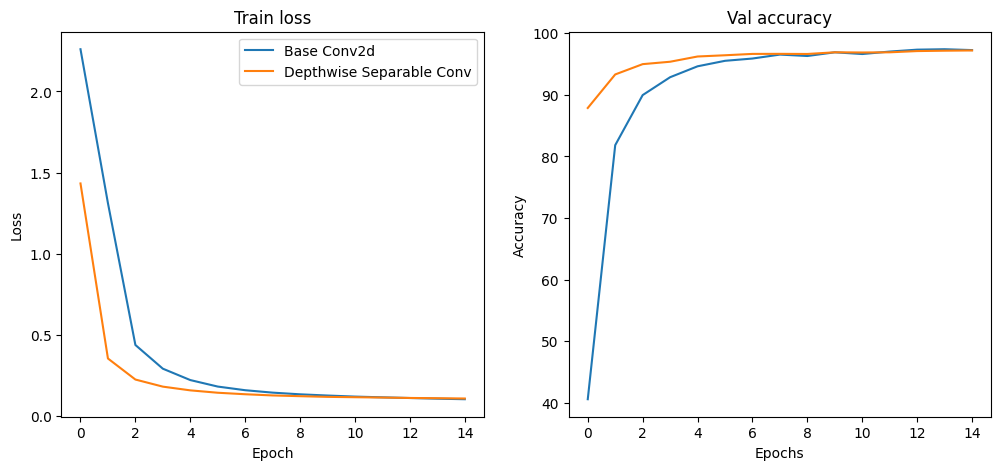

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(avg_loss, label='Base Conv2d')
ax1.plot(avg_loss_dws, label='Depthwise Separable Conv')
ax1.set_title('Train loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(val_acc, label='Base Conv2d')
ax2.plot(val_acc_dws, label='Depthwise Separable Conv')
ax2.set_title('Val accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy');

In [12]:
pd.DataFrame({
    'Conv2d': [np.min(avg_loss), np.max(val_acc), np.mean(base_cnn_train_time)], 
    'Depthwise Separable Conv': [np.min(avg_loss_dws), np.max(val_acc_dws), np.mean(base_cnn_train_time_dws)]
}, index=['Min loss', 'Max Acc', 'Avg time per Epoch'])

,Conv2d,Depthwise Separable Conv
Min loss,0.103660,0.108110
Max Acc,97.380000,97.180000
Avg time per Epoch,5.544898,6.896747


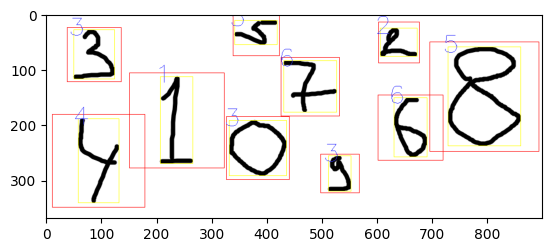

In [13]:
#Model with base conv2d
infer_test_cases('/base_cnn.onnx', figsize=(6, 6))

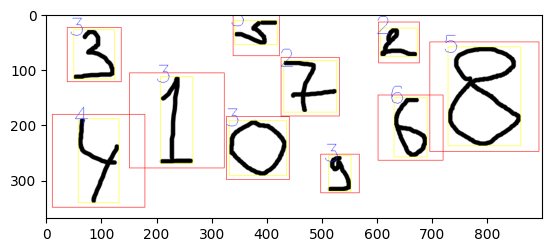

In [14]:
#Model with depthwise separable conv
infer_test_cases('/base_cnn_with_dws_conv.onnx', figsize=(6, 6))

#### 1. На валидационной выборке MNIST модель с обычными conv2d показала себя лучше
#### 2. На тестовых примерах обе модели плохо себя показали

### 8Б. Добавление аугментации

In [15]:
aug_transform = transforms.Compose([
    transforms.RandomRotation(degrees=30),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.RandomResizedCrop(size=28, scale=(0.3, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

aug_trainset = datasets.MNIST(path, download=True, train=True, transform=aug_transform)
aug_trainloader = DataLoader(aug_trainset, batch_size=256, shuffle=True)

### CNN with Depthwise-Separable Conv layers

In [16]:
dws_cnn_aug = BaseDepthwiseCNN()

num_epochs = 15
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(dws_cnn_aug.parameters(), lr=0.005, momentum=0.9, weight_decay=0.01)

avg_loss_dws_aug, val_acc_dws_aug, base_cnn_train_time_dws_aug = do_train(
    dws_cnn_aug, aug_trainloader, testloader, criterion, optimizer, None, num_epochs, device,
) 

dws_cnn_aug.to('cpu')
torch.onnx.export(dws_cnn_aug, onnx_test_x, path+'/dws_conv_with_aug.onnx')

100%|██████████| 15/15 [02:59<00:00, 11.94s/it]


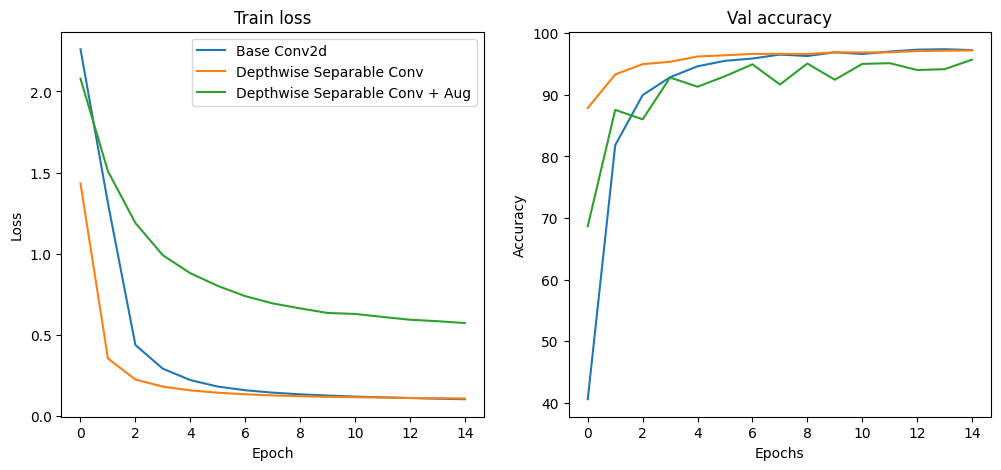

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(avg_loss, label='Base Conv2d')
ax1.plot(avg_loss_dws, label='Depthwise Separable Conv')
ax1.plot(avg_loss_dws_aug, label='Depthwise Separable Conv + Aug')
ax1.set_title('Train loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(val_acc, label='Base Conv2d')
ax2.plot(val_acc_dws, label='Depthwise Separable Conv')
ax2.plot(val_acc_dws_aug, label='Depthwise Separable Conv + Aug')
ax2.set_title('Val accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy');

In [18]:
pd.DataFrame({
    'Conv2d': [np.min(avg_loss), np.max(val_acc), np.mean(base_cnn_train_time)], 
    'Depthwise Separable Conv': [np.min(avg_loss_dws), np.max(val_acc_dws), np.mean(base_cnn_train_time_dws)],
    'Depthwise Separable Conv + Aug': [np.min(avg_loss_dws_aug), np.max(val_acc_dws_aug), np.mean(base_cnn_train_time_dws_aug)]
}, index=['Min loss', 'Max Acc', 'Avg time per Epoch'])

,Conv2d,Depthwise Separable Conv,Depthwise Separable Conv + Aug
Min loss,0.103660,0.108110,0.572883
Max Acc,97.380000,97.180000,95.690000
Avg time per Epoch,5.544898,6.896747,11.076997


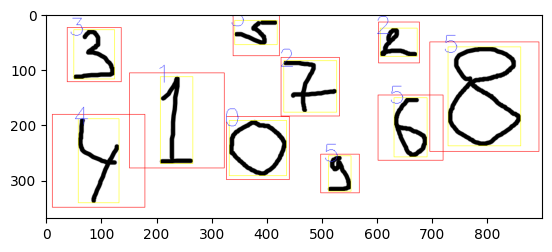

In [19]:
infer_test_cases('/dws_conv_with_aug.onnx', figsize=(6, 6))

#### Модель хоть и показывает accuracy на валидационной части MNIST ниже, чем модели без аугментации, но на тестовых примерах модель лучше определяет цифры

### 10Б. Модель с разпосзнование тестовых примеров

In [ ]:
aug_transform = transforms.Compose([
    transforms.RandomRotation(degrees=30),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.RandomResizedCrop(size=28, scale=(0.3, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

basic_transform = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Normalize((0.1307,), (0.3081,))
])

aug_trainset = datasets.MNIST(path, download=True, train=True, transform=aug_transform)
aug_trainloader = DataLoader(aug_trainset, batch_size=256, shuffle=True)

testset = datasets.MNIST(path, download=True, train=False, transform=basic_transform)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

#tensor for onnx convertation
onnx_test_x = torch.randn(64, 1, 28, 28)

In [ ]:
class MNISTDepthwiseNet(nn.Module):
    def __init__(self):
        super(MNISTDepthwiseNet, self).__init__()
        
        self.conv_block1 = nn.Sequential(
            DepthwiseSeparableConv(1, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            DepthwiseSeparableConv(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25)
        )

        self.conv_block2 = nn.Sequential(
            DepthwiseSeparableConv(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            DepthwiseSeparableConv(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25)
        )

        self.conv_block3 = nn.Sequential(
            DepthwiseSeparableConv(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, 1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25)
        )

        self.fcnn = nn.Sequential(
            nn.Linear(256*5*5, 128),
            nn.Linear(128, 10),
            nn.Dropout(0.5)
        )


    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = x.view(-1, 256*5*5)
        x = self.fcnn(x)
        return x

In [ ]:
dw_cnn = MNISTDepthwiseNet()

num_epochs = 15
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(dw_cnn.parameters(), lr=0.002, weight_decay=0.001)

avg_loss_best_model_10ep, val_acc_best_model_10ep, train_time_best_model = do_train(
    dw_cnn, 
    aug_trainloader, 
    testloader, 
    criterion, 
    optimizer, 
    scheduler=None, 
    num_epochs=num_epochs, 
    device=device,
    logging=True,
) 

  7%|▋         | 1/15 [01:07<15:41, 67.27s/it]

2.916671529222042


 13%|█▎        | 2/15 [02:14<14:36, 67.39s/it]

1.795082890226486


 20%|██        | 3/15 [03:19<13:15, 66.30s/it]

...

1.0529322253896836


 93%|█████████▎| 14/15 [15:32<01:06, 66.03s/it]

1.05223491191864


100%|██████████| 15/15 [16:38<00:00, 66.56s/it]

1.0357668014282877


In [ ]:
dw_cnn.to('cpu')
torch.onnx.export(dw_cnn, onnx_test_x, path+'/dws_cnn_best_model.onnx')

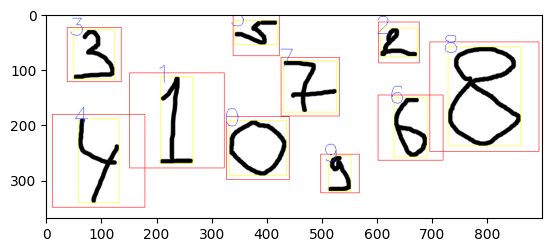

In [ ]:
infer_test_cases('/dws_cnn_best_model.onnx', figsize=(6, 6))

#### Модели удалось правильно классифицировать все цифры на тестовом примере